In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================
# TRANSFORM (SAMA SEPERTI TEST)
# =========================
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# =========================
# LOAD DATASET EKSTERNAL
# =========================
external_dataset = datasets.ImageFolder(
    root=r"D:\REVA\skripsi\01. Dataset\02. Eksternal\Eksternal_Dataset",
    transform=test_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False
)

class_names = external_dataset.classes

print("Jumlah data eksternal:", len(external_dataset))
print("Class:", class_names)

Jumlah data eksternal: 400
Class: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


In [2]:
import torch

# =========================
# DEVICE SETTING
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device yang digunakan:", device)

Device yang digunakan: cpu


In [3]:
import torchvision.models as models
import torch
import torch.nn as nn

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4

# =========================
# LOAD SQUEEZENET
# =========================
model_squeeze = models.squeezenet1_1(pretrained=True)

# =========================
# AMBIL JUMLAH FEATURE
# =========================
in_features = model_squeeze.classifier[1].in_channels

# =========================
# CLASSIFIER
# =========================
model_squeeze.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Dropout(0.5),
    nn.Linear(in_features, num_classes)
)

# =========================
# LOAD WEIGHT MODEL
# =========================
model_path = r"D:\REVA\skripsi\02. Code\01. SqueezeNet\best_squeezenet_fixed_feature_revisi.pth"

model_squeeze.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model_squeeze.to(device)

model.eval()

print("Model SqueezeNet berhasil dimuat")

Model SqueezeNet berhasil dimuat


C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
from sklearn.metrics import accuracy_score

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in external_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

external_accuracy = accuracy_score(all_labels, all_preds)

print("\n=== HASIL TEST DATASET EKSTERNAL (SqueezeNet) ===")
print(f"External Accuracy : {external_accuracy:.4f}")


=== HASIL TEST DATASET EKSTERNAL (SqueezeNet) ===
External Accuracy : 0.5900


In [5]:
from sklearn.metrics import classification_report

print("\n=== Classification Report (SqueezeNet - External Dataset) ===")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)


=== Classification Report (SqueezeNet - External Dataset) ===
                      precision    recall  f1-score   support

            cataract       0.76      0.82      0.79       100
diabetic_retinopathy       0.38      0.53      0.45       100
            glaucoma       0.66      0.93      0.78       100
              normal       0.57      0.08      0.14       100

            accuracy                           0.59       400
           macro avg       0.59      0.59      0.54       400
        weighted avg       0.59      0.59      0.54       400



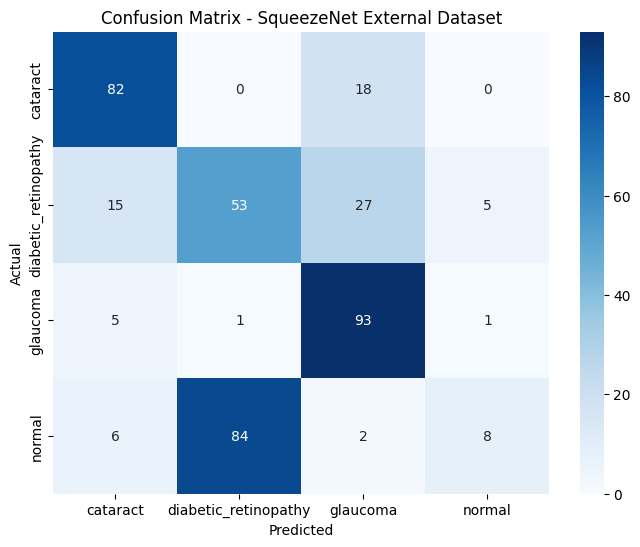

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SqueezeNet External Dataset")

plt.show()


Jumlah misclassification per kelas:
cataract: 3
diabetic_retinopathy: 3
glaucoma: 3
normal: 3

Menampilkan kelas: cataract


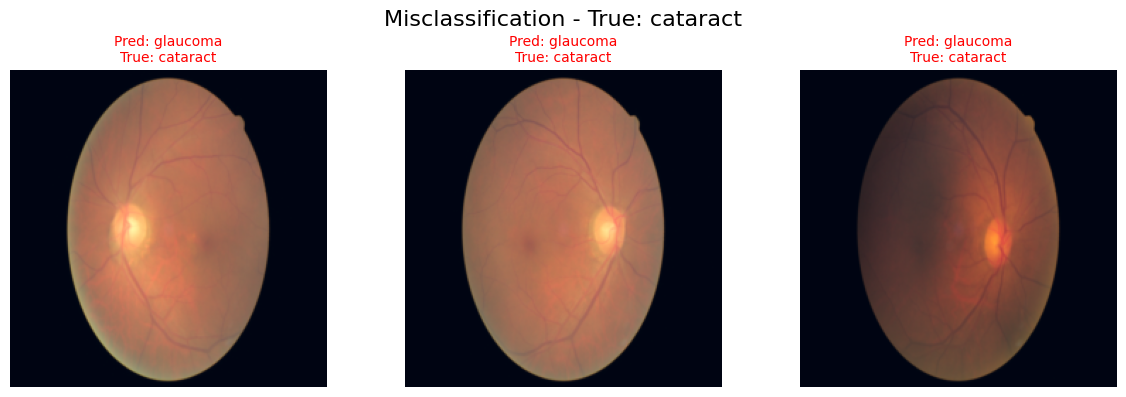


Menampilkan kelas: diabetic_retinopathy


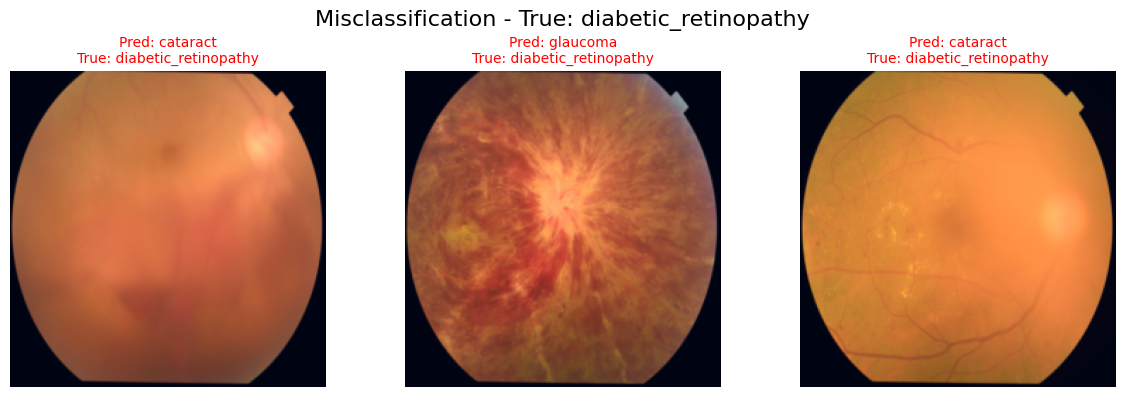


Menampilkan kelas: glaucoma


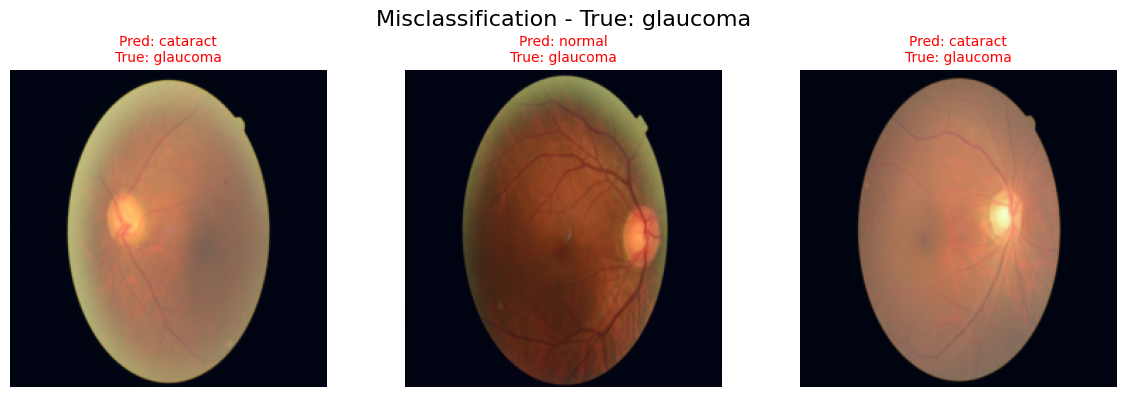


Menampilkan kelas: normal


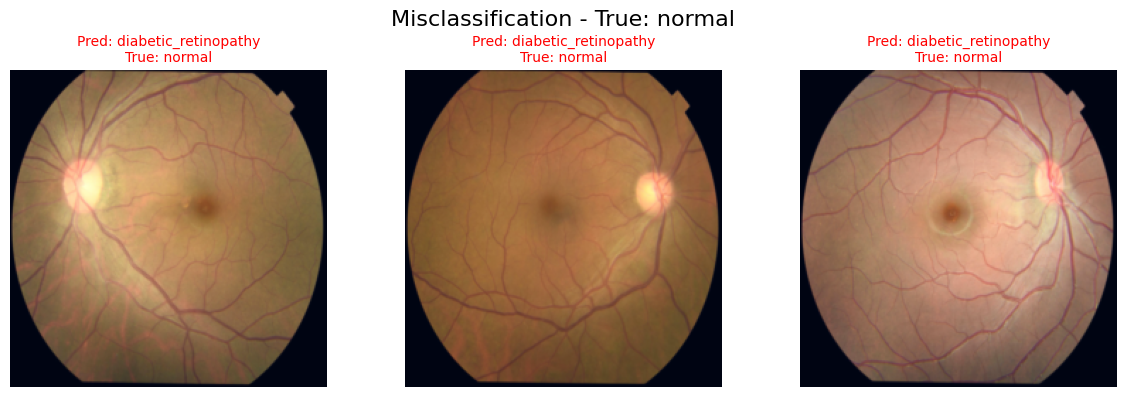

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import torch

model.eval()

class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

misclassified_per_class = defaultdict(list)
max_per_class = 3

# ===============================
# KUMPULKAN DATA
# ===============================
for images, labels in external_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(labels)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        if true_label != pred_label:
            if len(misclassified_per_class[true_label]) < max_per_class:
                misclassified_per_class[true_label].append(
                    (images[i].cpu(), pred_label)
                )

# ===============================
# DEBUG (PENTING)
# ===============================
print("\nJumlah misclassification per kelas:")
for k in range(len(class_names)):
    print(f"{class_names[k]}: {len(misclassified_per_class[k])}")

# ===============================
# VISUALISASI
# ===============================
for true_label, samples in misclassified_per_class.items():

    if len(samples) == 0:
        continue  # skip kalau tidak ada error

    print(f"\nMenampilkan kelas: {class_names[true_label]}")

    fig, axes = plt.subplots(1, max_per_class, figsize=(12, 4))

    if max_per_class == 1:
        axes = [axes]

    fig.suptitle(
        f"Misclassification - True: {class_names[true_label]}",
        fontsize=16
    )

    for i in range(max_per_class):

        ax = axes[i]

        if i < len(samples):
            image, pred_label = samples[i]

            img = image.permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())

            ax.imshow(img)
            ax.set_title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color='red',
                fontsize=10
            )
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


Correct: cataract


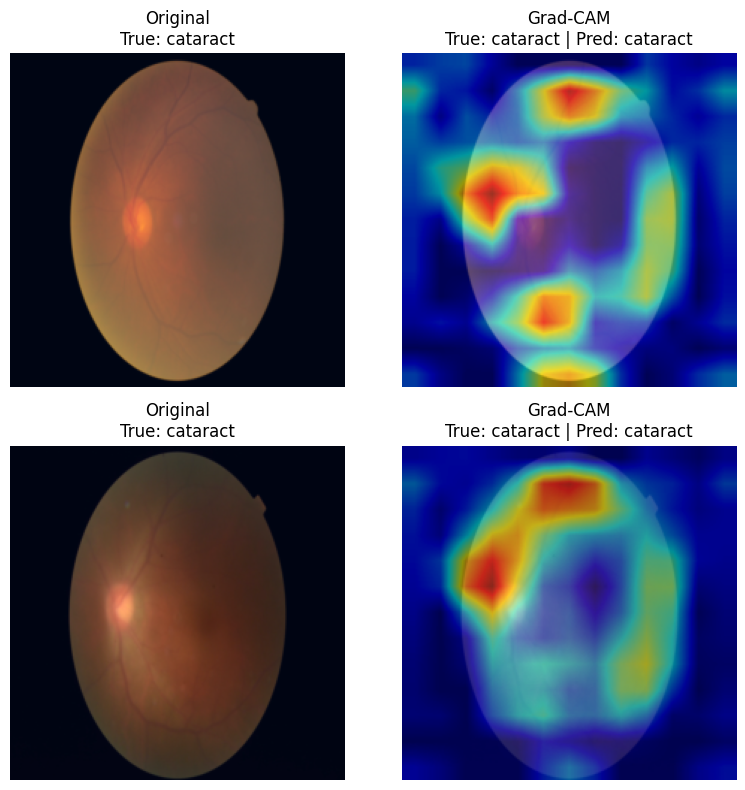


Correct: diabetic_retinopathy


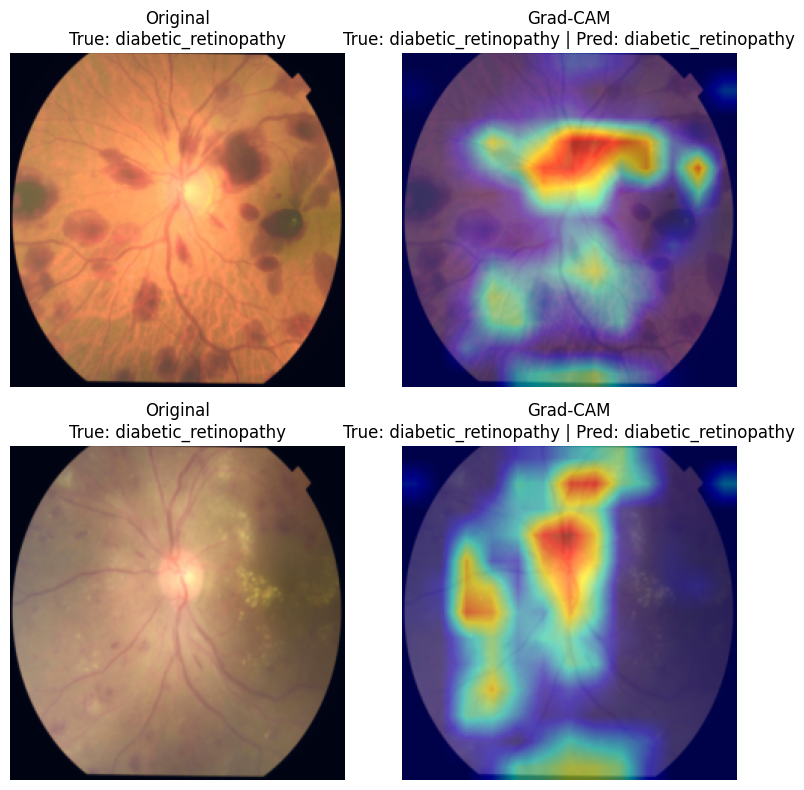


Correct: glaucoma


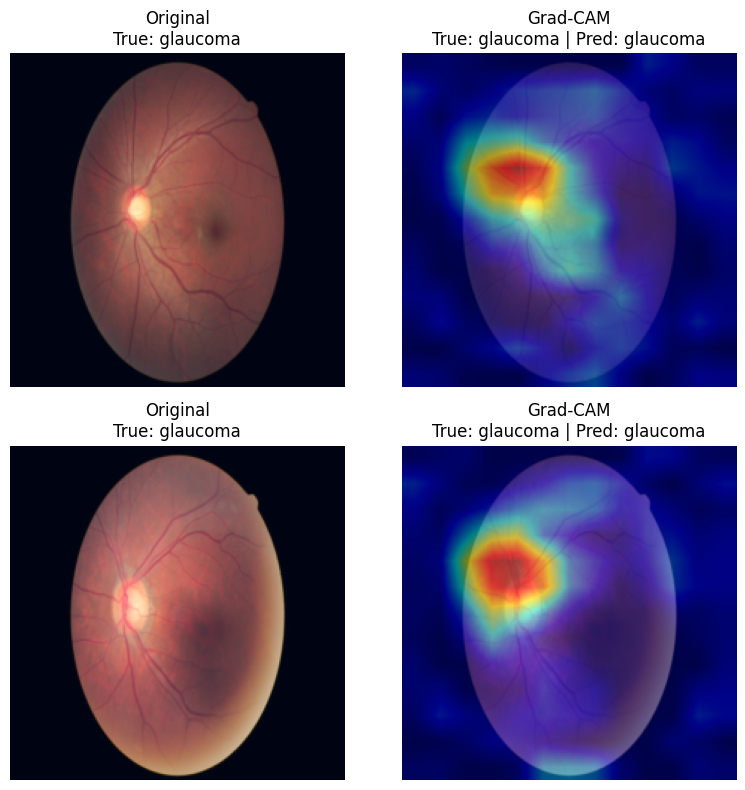


Correct: normal


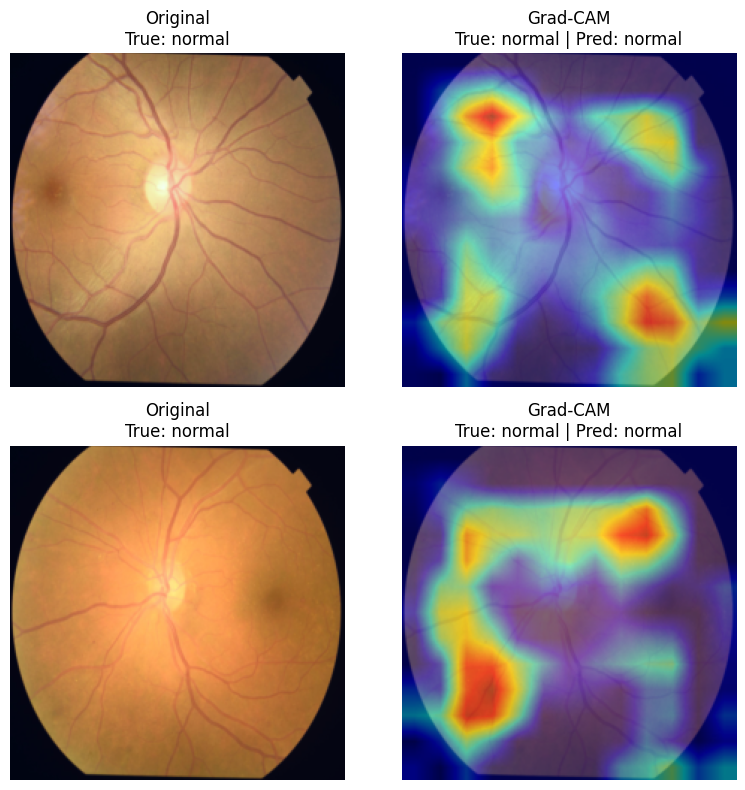

In [8]:
# ===============================
# VISUALISASI PREDIKSI BENAR (SQUEEZENET)
# ===============================
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.eval()

class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
num_classes = len(class_names)

correct_samples = defaultdict(list)
max_per_class = 2  # ambil 2 contoh benar per kelas

# ===============================
# AMBIL DATA BENAR
# ===============================
for images, labels in external_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(labels)):
        t = labels[i].item()
        p = preds[i].item()

        if t == p:
            if len(correct_samples[t]) < max_per_class:
                correct_samples[t].append(images[i].cpu())

# ===============================
# GRAD-CAM SETUP (SQUEEZENET)
# ===============================
# 🔥 Layer terbaik untuk SqueezeNet
target_layers = [model.features[12].expand3x3]

# Aktifkan gradient (penting untuk Grad-CAM)
for param in model.parameters():
    param.requires_grad = True

cam = GradCAM(model=model, target_layers=target_layers)

# ===============================
# VISUALISASI
# ===============================
for class_id, image_list in correct_samples.items():

    if len(image_list) == 0:
        continue

    print(f"\nCorrect: {class_names[class_id]}")

    fig, axes = plt.subplots(len(image_list), 2, figsize=(8, 4 * len(image_list)))

    if len(image_list) == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, image in enumerate(image_list):

        input_tensor = image.unsqueeze(0).to(device)

        try:
            grayscale_cam = cam(
                input_tensor=input_tensor,
                targets=[ClassifierOutputTarget(class_id)]
            )[0]
        except Exception as e:
            print(f"[ERROR] Grad-CAM gagal: {e}")
            continue

        img = image.permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

        # ORIGINAL
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Original\nTrue: {class_names[class_id]}")
        axes[idx, 0].axis("off")

        # GRAD-CAM
        axes[idx, 1].imshow(visualization)
        axes[idx, 1].set_title(
            f"Grad-CAM\nTrue: {class_names[class_id]} | Pred: {class_names[class_id]}"
        )
        axes[idx, 1].axis("off")

    plt.tight_layout()
    plt.show()


=== CONFUSION MATRIX (RAW) ===
[[82  0 18  0]
 [15 53 27  5]
 [ 5  1 93  1]
 [ 6 84  2  8]]

=== DAFTAR ERROR VALID ===
True: cataract → Pred: glaucoma | Jumlah: 18
True: diabetic_retinopathy → Pred: cataract | Jumlah: 15
True: diabetic_retinopathy → Pred: glaucoma | Jumlah: 27
True: diabetic_retinopathy → Pred: normal | Jumlah: 5
True: glaucoma → Pred: cataract | Jumlah: 5
True: glaucoma → Pred: diabetic_retinopathy | Jumlah: 1
True: glaucoma → Pred: normal | Jumlah: 1
True: normal → Pred: cataract | Jumlah: 6
True: normal → Pred: diabetic_retinopathy | Jumlah: 84
True: normal → Pred: glaucoma | Jumlah: 2

Misclass: True cataract → Pred glaucoma


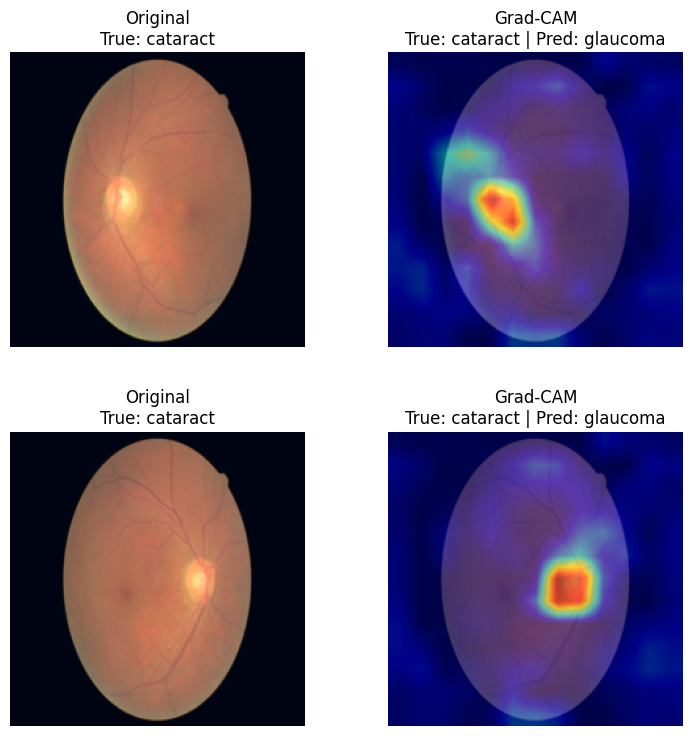


Misclass: True diabetic_retinopathy → Pred cataract


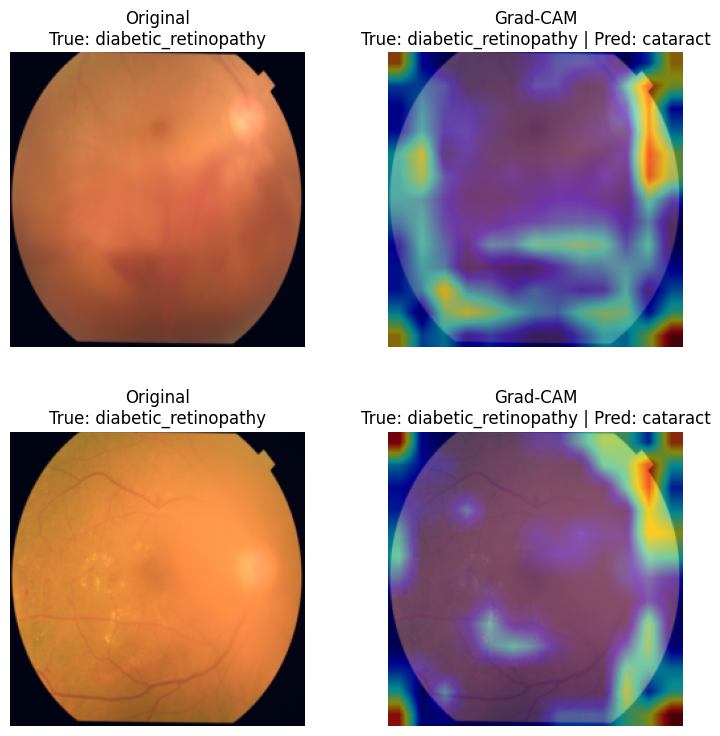


Misclass: True diabetic_retinopathy → Pred glaucoma


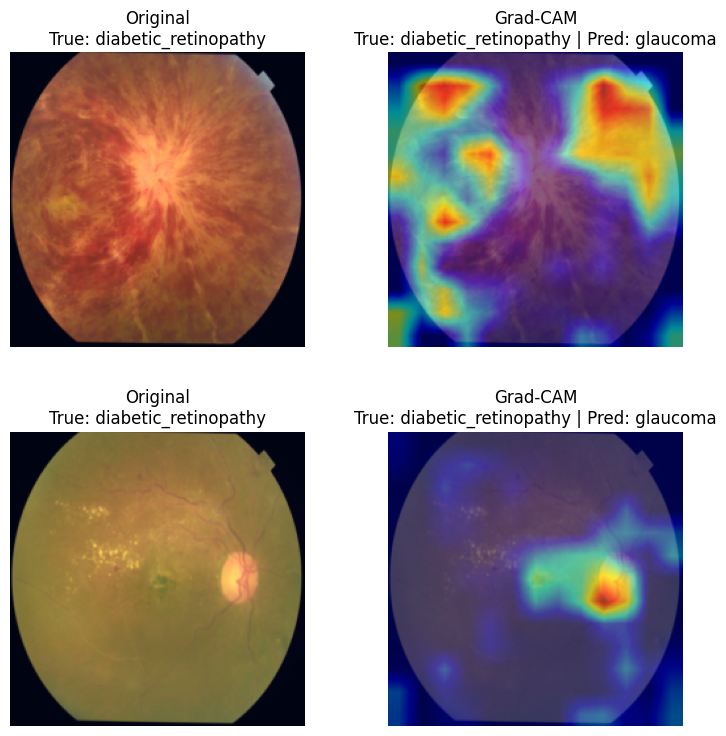


Misclass: True diabetic_retinopathy → Pred normal


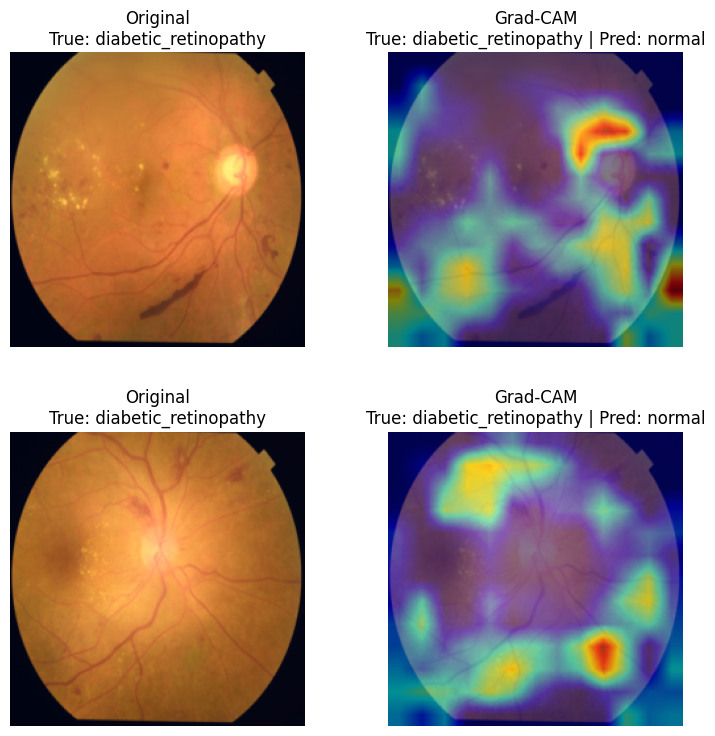


Misclass: True glaucoma → Pred cataract


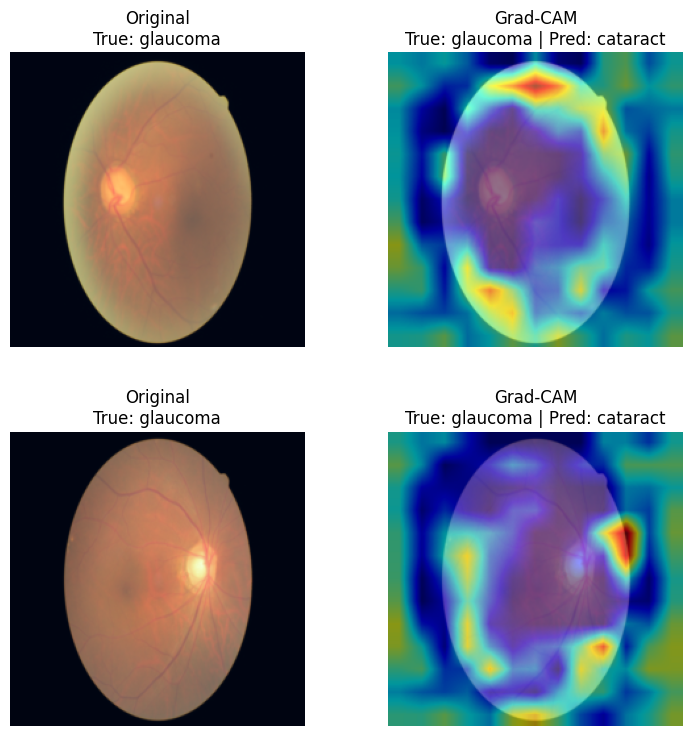


Misclass: True glaucoma → Pred normal


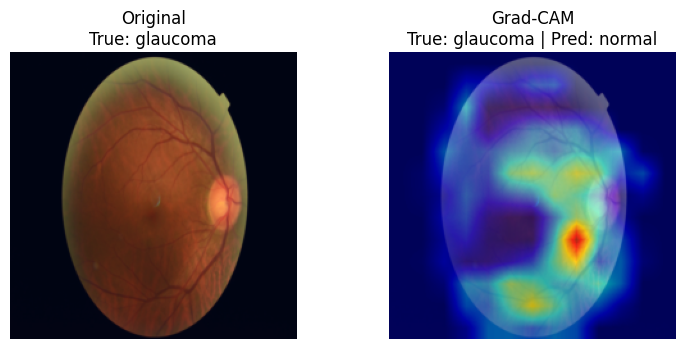


Misclass: True glaucoma → Pred diabetic_retinopathy


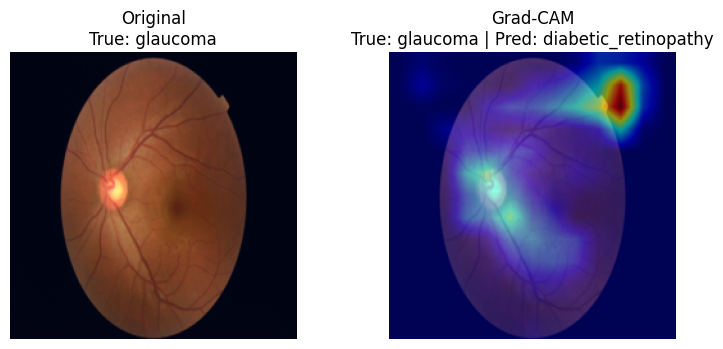


Misclass: True normal → Pred diabetic_retinopathy


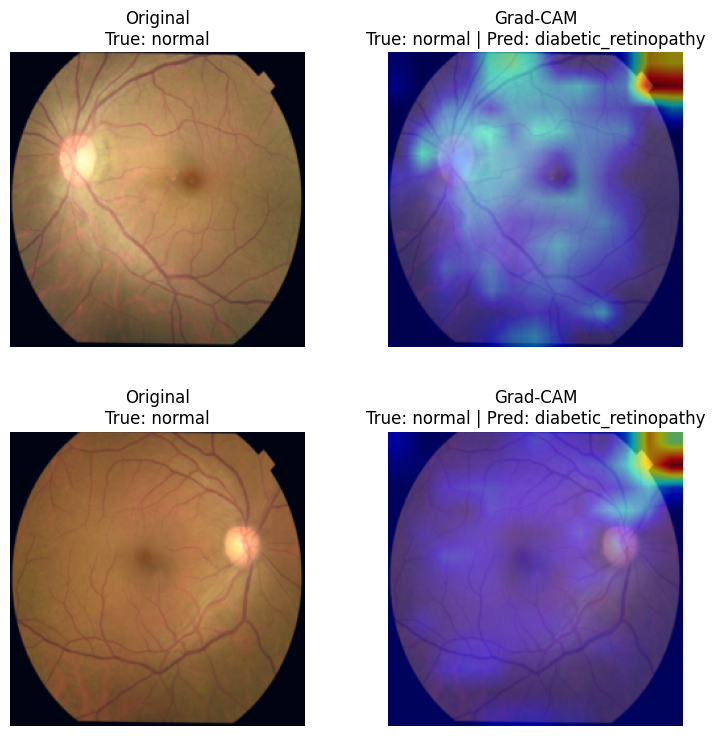


Misclass: True normal → Pred glaucoma


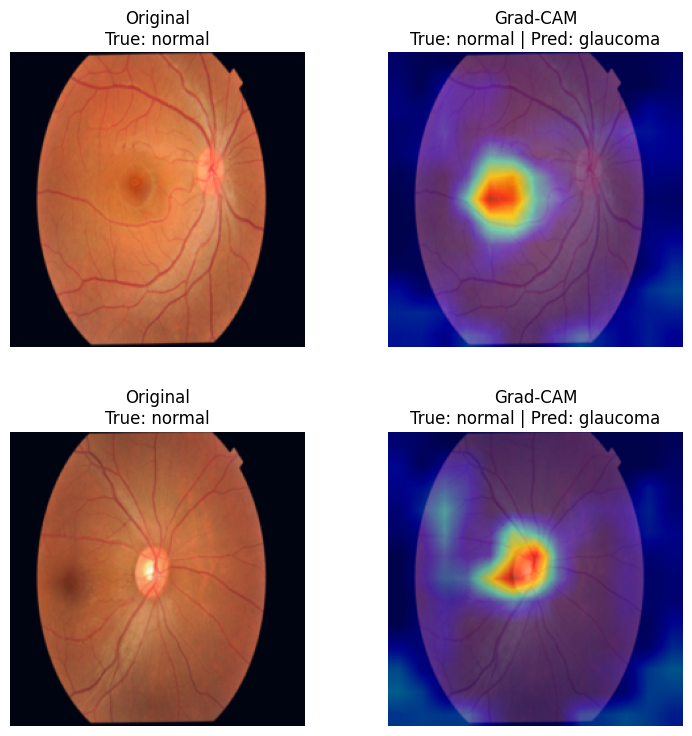


Misclass: True normal → Pred cataract


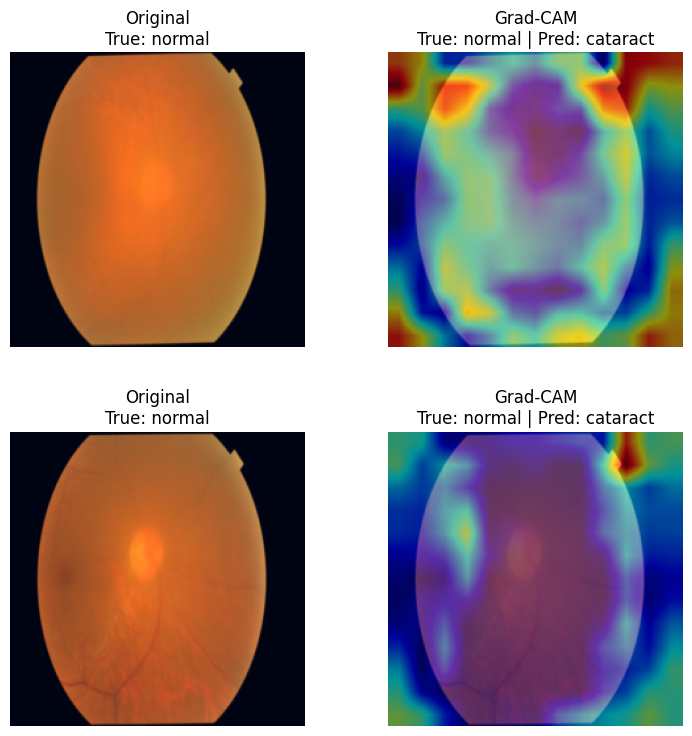

In [9]:
# ===============================
# CONFUSION MATRIX (EKSTERNAL)
# ===============================
import numpy as np
import torch

model.eval()

class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
num_classes = len(class_names)

conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for images, labels in external_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for t, p in zip(labels, preds):
        conf_matrix[t.item(), p.item()] += 1

print("\n=== CONFUSION MATRIX (RAW) ===")
print(conf_matrix)

print("\n=== DAFTAR ERROR VALID ===")
valid_pairs = []

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and conf_matrix[i][j] > 0:
            print(f"True: {class_names[i]} → Pred: {class_names[j]} | Jumlah: {conf_matrix[i][j]}")
            valid_pairs.append((i, j))

# ===============================
# AMBIL MISCLASSIFICATION
# ===============================
from collections import defaultdict

misclassified = defaultdict(list)
max_per_pair = 2

for images, labels in external_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(labels)):
        t = labels[i].item()
        p = preds[i].item()

        if (t, p) in valid_pairs:
            if len(misclassified[(t, p)]) < max_per_pair:
                misclassified[(t, p)].append(images[i].cpu())

# ===============================
# GRAD-CAM
# ===============================
# 🔥 Layer terbaik untuk SqueezeNet
target_layers = [model.features[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# ===============================
# VISUALISASI MISCLASS
# ===============================
for (true_label, pred_label), image_list in misclassified.items():

    print(f"\nMisclass: True {class_names[true_label]} → Pred {class_names[pred_label]}")

    fig, axes = plt.subplots(len(image_list), 2, figsize=(8, 4 * len(image_list)))

    if len(image_list) == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx, image in enumerate(image_list):

        input_tensor = image.unsqueeze(0).to(device)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred_label)]
        )[0]

        img = image.permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

        # ORIGINAL
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Original\nTrue: {class_names[true_label]}")
        axes[idx, 0].axis("off")

        # GRAD-CAM
        axes[idx, 1].imshow(visualization)
        axes[idx, 1].set_title(
            f"Grad-CAM\nTrue: {class_names[true_label]} | Pred: {class_names[pred_label]}"
        )
        axes[idx, 1].axis("off")

    plt.tight_layout(pad=3.0)
    plt.show()